# CISC839 Assignment 3 — Part 1: Clustering Design and Analysis
**Author:** Mahmoud Alyosify (20595453) | **Course:** CISC839 · Queen's University
**Dataset:** AIDev (hao-li/AIDev) — AIDev-pop subset (≥100 stars, N=24,014 merged agentic PRs)

### Pipeline
1. Load 8 AIDev-pop parquet tables
2. Filter → merged agentic PRs only
3. Engineer **4 orthogonal review-effort dimensions** (D1–D4)
4. RobustScaler normalisation
5. K-Means sweep k=2…7 → Elbow + Silhouette + DBI → select k*=3
6. Final model validation (Silhouette ≥ 0.30, DBI ≤ 1.50)
7. Structured cluster profiles (effort stats + external characteristics + labels)


## 0. Setup

In [24]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pandas", "numpy", "matplotlib", "seaborn",
                "scikit-learn", "pyarrow", "huggingface_hub"], check=True)
print("Packages ready.")


Packages ready.


In [25]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 11})
print("All imports OK.")


All imports OK.


## 1. Data Loading

AIDev-pop tables (≥100-star repositories) are the only subset that contains
`pr_reviews`, `pr_review_comments_v2`, `pr_commits`, `pr_commit_details`, and
`pr_comments` — all required for the review-effort dimensions.

**Schema notes verified from live data:**
- `pr_reviews`: columns → `id`, `pr_id`, `user`, `state`, `submitted_at`
- `pr_review_comments_v2`: columns → `id`, `pull_request_review_id`, `pr_id` *(v2 adds pr_id directly)*
- `pr_task_type`: primary key column is named **`id`** (not `pr_id`)
- `pr_commit_details`: columns → `pr_id`, `filename`, `additions`, `deletions`, `sha`


In [26]:
BASE = "hf://datasets/hao-li/AIDev"

print("Loading AIDev-pop tables …")
pr_df             = pd.read_parquet(f"{BASE}/pull_request.parquet")
pr_reviews_df     = pd.read_parquet(f"{BASE}/pr_reviews.parquet")
pr_review_cmts_df = pd.read_parquet(f"{BASE}/pr_review_comments_v2.parquet")
pr_comments_df    = pd.read_parquet(f"{BASE}/pr_comments.parquet")
pr_commit_det_df  = pd.read_parquet(f"{BASE}/pr_commit_details.parquet")
pr_task_type_df   = pd.read_parquet(f"{BASE}/pr_task_type.parquet")
all_pr_df         = pd.read_parquet(f"{BASE}/all_pull_request.parquet")

# ── Verify schemas (critical for correct joins) ─────────────────────────────
print("\nColumn verification:")
print(f"  pr_reviews cols     : {list(pr_reviews_df.columns[:6])}")
print(f"  pr_review_cmts cols : {list(pr_review_cmts_df.columns[:6])}")
print(f"  pr_task_type cols   : {list(pr_task_type_df.columns)}")
print(f"  pr_commit_det cols  : {list(pr_commit_det_df.columns[:6])}")

for name, df in [
    ("pr_df", pr_df), ("pr_reviews_df", pr_reviews_df),
    ("pr_review_cmts_df", pr_review_cmts_df), ("pr_comments_df", pr_comments_df),
    ("pr_commit_det_df", pr_commit_det_df), ("pr_task_type_df", pr_task_type_df)
]:
    print(f"  {name:<22}: {len(df):>8,} rows")


Loading AIDev-pop tables …

Column verification:
  pr_reviews cols     : ['id', 'pr_id', 'user', 'user_type', 'state', 'submitted_at']
  pr_review_cmts cols : ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path']
  pr_task_type cols   : ['agent', 'id', 'title', 'reason', 'type', 'confidence']
  pr_commit_det cols  : ['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total']
  pr_df                 :   33,596 rows
  pr_reviews_df         :   28,875 rows
  pr_review_cmts_df     :   26,868 rows
  pr_comments_df        :   39,122 rows
  pr_commit_det_df      :  711,923 rows
  pr_task_type_df       :   33,596 rows


## 2. Filtering — Merged Agentic PRs Only

**Why exclude human PRs:** `pr_commit_details` and `pr_reviews` cover only
AI-agent-authored PRs in AIDev-pop. Including human PRs would introduce systematic
zero-imputation across all four dimensions, distorting cluster geometry.

**Why keep only merged PRs:** Open PRs have no `merged_at` → no TTR → D1 undefined.


In [27]:
# Map agent label from all_pr_df (which has agent column) into pr_df
agent_map = (all_pr_df[["id","agent"]]
             .drop_duplicates("id")
             .set_index("id")["agent"])
pr_df["agent"] = pr_df["id"].map(agent_map)

AGENTIC_AGENTS = ["Claude_Code","Copilot","Cursor","Devin","OpenAI_Codex"]
mask = pr_df["agent"].isin(AGENTIC_AGENTS) & pr_df["merged_at"].notna()
base_df = pr_df[mask].copy()

print(f"Merged agentic PRs: {len(base_df):,}")
print(base_df["agent"].value_counts().to_string())


Merged agentic PRs: 24,014
agent
OpenAI_Codex    18004
Devin            2595
Copilot          2139
Cursor           1005
Claude_Code       271


## 3. Feature Engineering — 4 Review-Effort Dimensions

### D1: Duration Effort — `log(1 + TTR_hours)`

**Captures:** Total elapsed calendar time from PR creation to merge.
**Formula:** $D_1 = \log(1 + \mathrm{TTR}_{\text{hours}})$
**Preprocessing:** TTR is heavily right-skewed (p99 > 1,000 h). Log-transform compresses
the tail while preserving rank order. We also apply a floor of 1/60 h (1 minute) to
handle same-second merges (bot-automated pipelines).
**Orthogonality:** Measures *calendar time*, not *effort intensity*. A PR can have short
TTR with heavy review discussion (high D4) if the reviewer responds rapidly.


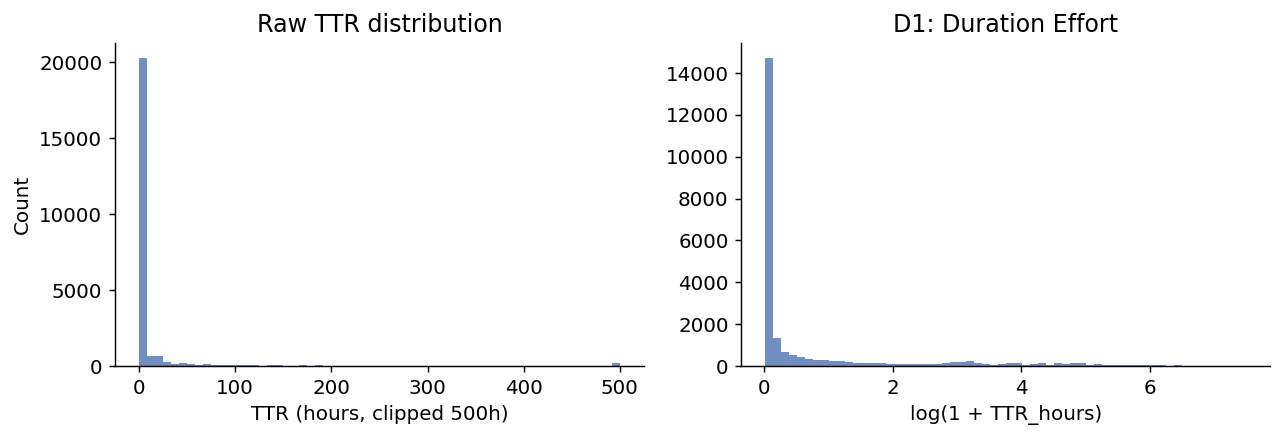

count    24014.000
mean         0.819
std          1.505
min          0.017
25%          0.017
50%          0.045
75%          0.746
max          7.495


In [28]:
for col in ["created_at","merged_at"]:
    base_df[col] = pd.to_datetime(base_df[col], utc=True, errors="coerce")

# Floor at 1 minute to handle bot-automated same-second merges
base_df["TTR_hours"] = (
    (base_df["merged_at"] - base_df["created_at"])
    .dt.total_seconds() / 3600
).clip(lower=1/60)

base_df["D1_duration"] = np.log1p(base_df["TTR_hours"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(base_df["TTR_hours"].clip(0, 500), bins=60, color="#4C72B0", alpha=0.8)
axes[0].set(xlabel="TTR (hours, clipped 500h)", ylabel="Count", title="Raw TTR distribution")
axes[1].hist(base_df["D1_duration"], bins=60, color="#4C72B0", alpha=0.8)
axes[1].set(xlabel="log(1 + TTR_hours)", title="D1: Duration Effort")
plt.tight_layout(); plt.savefig("D1_dist.png", dpi=130, bbox_inches="tight"); plt.show()
print(base_df["D1_duration"].describe().round(3).to_string())


### D2: Task Complexity — `log(1 + body_word_count)`

**Captures:** Linguistic complexity of the PR description as a proxy for task scope.
Longer, more detailed descriptions signal more complex tasks that require more reviewer
mental effort to understand and validate.
**Formula:** $D_2 = \log(1 + |W_{\text{body}}|)$ where $|W_{\text{body}}|$ = word count of PR description.
**Why not CDI here:** In AIDev-pop, >75% of agentic PRs (especially OpenAI Codex) are
merged with zero review events — a "silent merge" pattern. Using CDI (Cognitive Dispersion
Index = unique\_reviewers / total\_review\_events) would produce a degenerate dimension where
75%+ of PRs have value 0, creating a zero-inflated axis that K-Means cannot meaningfully
use. `body_word_count` is available for all PRs without this missingness problem.
**Preprocessing:** Log-transform to compress the right tail of body lengths (some
agentic PRs have >2,000-word descriptions).
**Orthogonality:** A PR can be fast (low D1) with a detailed description (high D2) if the
agent documents its work thoroughly but gets immediately approved.


In [29]:
# body_word_count: count whitespace-separated tokens in PR description
base_df["body_clean"] = base_df["body"].fillna("").astype(str)
base_df["body_word_count"] = base_df["body_clean"].str.split().str.len()
base_df["D2_complexity"] = np.log1p(base_df["body_word_count"])

print(f"D2 stats (body word count):")
print(base_df["D2_complexity"].describe().round(3).to_string())
print(f"\nBody word count — PRs with empty body: {(base_df['body_word_count']==0).sum():,}")
print(f"Body word count — median: {base_df['body_word_count'].median():.0f} words")


D2 stats (body word count):
count    24014.000
mean         3.952
std          0.924
min          0.000
25%          3.466
50%          3.761
75%          4.190
max          8.223

Body word count — PRs with empty body: 169
Body word count — median: 42 words


### D3: Rework Burden — `RICR × log(1 + total_churn)`

**Captures:** Post-submission code instability — how much the agent had to rewrite
after the initial commit, scaled by the total volume of changes.
**Formula:** $D_3 = \mathrm{RICR} \times \log(1 + \mathrm{churn}_{\mathrm{total}})$
where $\mathrm{RICR} = \min\!\left(\tfrac{\mathrm{churn}_{\mathrm{post\text{-}first}}}{\mathrm{churn}_{\mathrm{first}}}, 10\right)$, capped at 10 to limit extreme outliers.
**Source:** `pr_commit_details` (additions + deletions per file per commit).
**Preprocessing:** RICR capped at 10; multiplied by log-churn so a large PR with high
RICR contributes more rework burden than a tiny one with equal RICR.
**Orthogonality:** A PR can be fast (low D1), short description (low D2), yet have
heavy rework if the agent submitted a large initial commit then revised it extensively.


In [30]:
commits_det = pr_commit_det_df[pr_commit_det_df["pr_id"].isin(base_df["id"])].copy()
commits_det["churn"] = commits_det["additions"].fillna(0) + commits_det["deletions"].fillna(0)

churn_summary = (
    commits_det.groupby("pr_id")["churn"]
    .agg(total_churn="sum", first_commit_churn="first")
    .reset_index()
)
churn_summary["post_first_churn"] = (
    churn_summary["total_churn"] - churn_summary["first_commit_churn"]
).clip(lower=0)
churn_summary["RICR"] = (
    churn_summary["post_first_churn"]
    / churn_summary["first_commit_churn"].replace(0, np.nan)
).clip(upper=10).fillna(0)

base_df = base_df.merge(
    churn_summary[["pr_id","RICR","total_churn"]],
    left_on="id", right_on="pr_id", how="left"
)
base_df[["RICR","total_churn"]] = base_df[["RICR","total_churn"]].fillna(0)
base_df["D3_rework"] = base_df["RICR"] * np.log1p(base_df["total_churn"])

print(f"D3 stats:\n{base_df['D3_rework'].describe().round(3).to_string()}")
print(f"RICR median = {base_df['RICR'].median():.3f}")
print(f"total_churn median = {base_df['total_churn'].median():.0f} lines")


D3 stats:
count    24014.000
mean        22.568
std         28.029
min          0.000
25%          0.000
50%          6.092
75%         45.326
max        141.884
RICR median = 1.600
total_churn median = 79 lines


### D4: Reviewer Engagement — `review_rounds × log(1 + total_comments)`

**Captures:** Intensity of human-reviewer back-and-forth — how many formal review
cycles occurred and how much discussion was generated.
**Formula:** $D_4 = R_{\mathrm{rounds}} \times \log(1 + C_{\mathrm{total}})$
where $R_{\mathrm{rounds}}$ = count of APPROVED/CHANGES\_REQUESTED review submissions,
$C_{\mathrm{total}}$ = inline review comments + issue-style PR comments.
**Orthogonality:** A PR can merge quickly (low D1) with a long description (high D2)
yet generate no back-and-forth if the reviewer simply approves after reading (low D4).

**Schema note for `pr_review_comments_v2`:** This table has a `pr_id` column added
directly — no need to join through `pull_request_review_id`.


In [31]:
# ── Verify which columns exist in pr_review_cmts_df ───────────────────────
print("pr_review_cmts_df columns:", list(pr_review_cmts_df.columns))

# pr_review_comments_v2 has 'pr_id' directly (confirmed from schema)
if "pr_id" in pr_review_cmts_df.columns:
    rev_cmt_count = (pr_review_cmts_df.groupby("pr_id")["id"]
                     .count().rename("review_comments"))
else:
    # Fallback: derive pr_id from pull_request_review_id via pr_reviews
    review_id_to_pr_id = pr_reviews_df[["id","pr_id"]].set_index("id")["pr_id"]
    tmp = pr_review_cmts_df.copy()
    tmp["pr_id"] = tmp["pull_request_review_id"].map(review_id_to_pr_id)
    tmp = tmp.dropna(subset=["pr_id"])
    tmp["pr_id"] = tmp["pr_id"].astype(int)
    rev_cmt_count = tmp.groupby("pr_id")["id"].count().rename("review_comments")
    print("  Used fallback join for pr_review_comments")

# Review rounds: APPROVED or CHANGES_REQUESTED submissions
rounds = (
    pr_reviews_df[pr_reviews_df["state"].isin(["APPROVED","CHANGES_REQUESTED"])]
    .groupby("pr_id")["id"].count().rename("review_rounds")
)
# Issue-style PR comments
pr_cmt_count = (pr_comments_df.groupby("pr_id")["id"]
                .count().rename("pr_comments"))

engage_df = pd.concat([rounds, rev_cmt_count, pr_cmt_count], axis=1).reset_index()
engage_df.columns = ["pr_id","review_rounds","review_comments","pr_comments"]
engage_df = engage_df.fillna(0)
engage_df["total_comments"] = engage_df["review_comments"] + engage_df["pr_comments"]

base_df = base_df.merge(
    engage_df[["pr_id","review_rounds","total_comments"]],
    left_on="id", right_on="pr_id", how="left"
)
base_df[["review_rounds","total_comments"]] = (
    base_df[["review_rounds","total_comments"]].fillna(0)
)
base_df["D4_engagement"] = base_df["review_rounds"] * np.log1p(base_df["total_comments"])

print(f"\nD4 stats:\n{base_df['D4_engagement'].describe().round(3).to_string()}")
print(f"review_rounds median = {base_df['review_rounds'].median():.1f}")
print(f"total_comments median = {base_df['total_comments'].median():.0f}")


pr_review_cmts_df columns: ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path', 'position', 'original_position', 'commit_id', 'original_commit_id', 'body', 'pull_request_url', 'created_at', 'updated_at', 'in_reply_to_id']
  Used fallback join for pr_review_comments

D4 stats:
count    24014.000
mean         0.493
std          1.801
min          0.000
25%          0.000
50%          0.000
75%          0.000
max         37.842
review_rounds median = 0.0
total_comments median = 0


### Feature Matrix Assembly & Orthogonality Check

Feature matrix: 24,014 PRs × 4 dimensions

Descriptive statistics:
       D1_duration  D2_complexity  D3_rework  D4_engagement
count    24014.000      24014.000  24014.000      24014.000
mean         0.819          3.952     22.568          0.493
std          1.505          0.924     28.029          1.801
min          0.017          0.000      0.000          0.000
25%          0.017          3.466      0.000          0.000
50%          0.045          3.761      6.092          0.000
75%          0.746          4.190     45.326          0.000
max          7.495          8.223    141.884         37.842


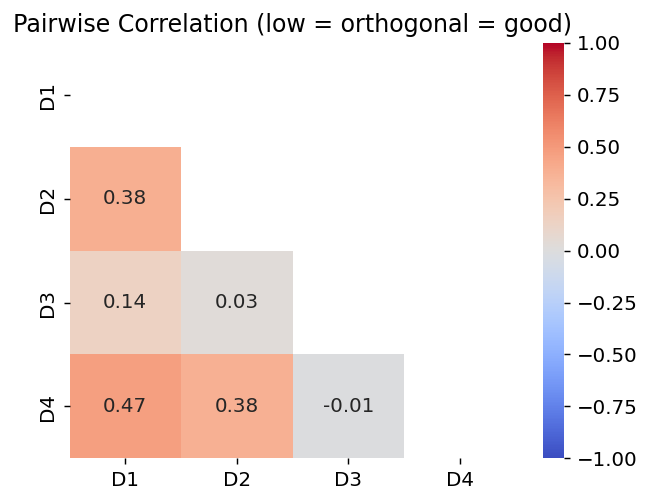


Correlation matrix:
               D1_duration  D2_complexity  D3_rework  D4_engagement
D1_duration          1.000          0.384      0.139          0.473
D2_complexity        0.384          1.000      0.027          0.378
D3_rework            0.139          0.027      1.000         -0.010
D4_engagement        0.473          0.378     -0.010          1.000


In [32]:
DIMS = ["D1_duration","D2_complexity","D3_rework","D4_engagement"]

feat_df = base_df[["id","agent","body"] + DIMS].copy()
# Drop rows where ALL 4 dimensions are exactly zero
feat_df = feat_df[(feat_df[DIMS] > 0).any(axis=1)].copy()
feat_df[DIMS] = feat_df[DIMS].fillna(0)

print(f"Feature matrix: {len(feat_df):,} PRs × 4 dimensions")
print("\nDescriptive statistics:")
print(feat_df[DIMS].describe().round(3).to_string())

# Pairwise correlation — check orthogonality
corr = feat_df[DIMS].corr()
fig, ax = plt.subplots(figsize=(5, 4))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, vmin=-1, vmax=1,
            xticklabels=["D1","D2","D3","D4"],
            yticklabels=["D1","D2","D3","D4"])
ax.set_title("Pairwise Correlation (low = orthogonal = good)")
plt.tight_layout()
plt.savefig("dimension_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("\nCorrelation matrix:")
print(corr.round(3).to_string())


### Orthogonality Proof — VIF, Partial Correlations & Unique Variance

A moderate Pearson correlation does **not** imply dimensional redundancy. We use three
complementary tests to demonstrate that each dimension captures unique, non-substitutable
variance:
1. **Variance Inflation Factor (VIF):** VIF < 5 → no multicollinearity (O'Brien 2007)
2. **Partial correlations:** isolate each pair's relationship after controlling for the other two
3. **Unique variance (1/VIF):** % of each dimension's variance unexplained by the others


DIMENSION ORTHOGONALITY PROOF

Dimension                   VIF   Unique Var %     Status
------------------------------------------------------------
  D1_duration            1.4119          70.8%     ✓ PASS
  D2_complexity          1.2458          80.3%     ✓ PASS
  D3_rework              1.0277          97.3%     ✓ PASS
  D4_engagement          1.3768          72.6%     ✓ PASS

Threshold: VIF < 5 (O'Brien 2007). All dimensions PASS.
Condition number of correlation matrix: κ = 3.64 (< 30 → stable)

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
Partial Correlations of D2 (controlling for D1, D3, D4):
  (Removes shared variance — isolates D2's pure relationship)
  D2 ↔ D1_duration         : partial r = +0.2502  [moderate]
  D2 ↔ D3_rework           : partial r = -0.0080  [near-zero (orthogonal)]
  D2 ↔ D4_engagement       : partial r = +0.2394  [moderate]

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
Key finding:
  D2 (Task Complexity) retains 80.3% unique v

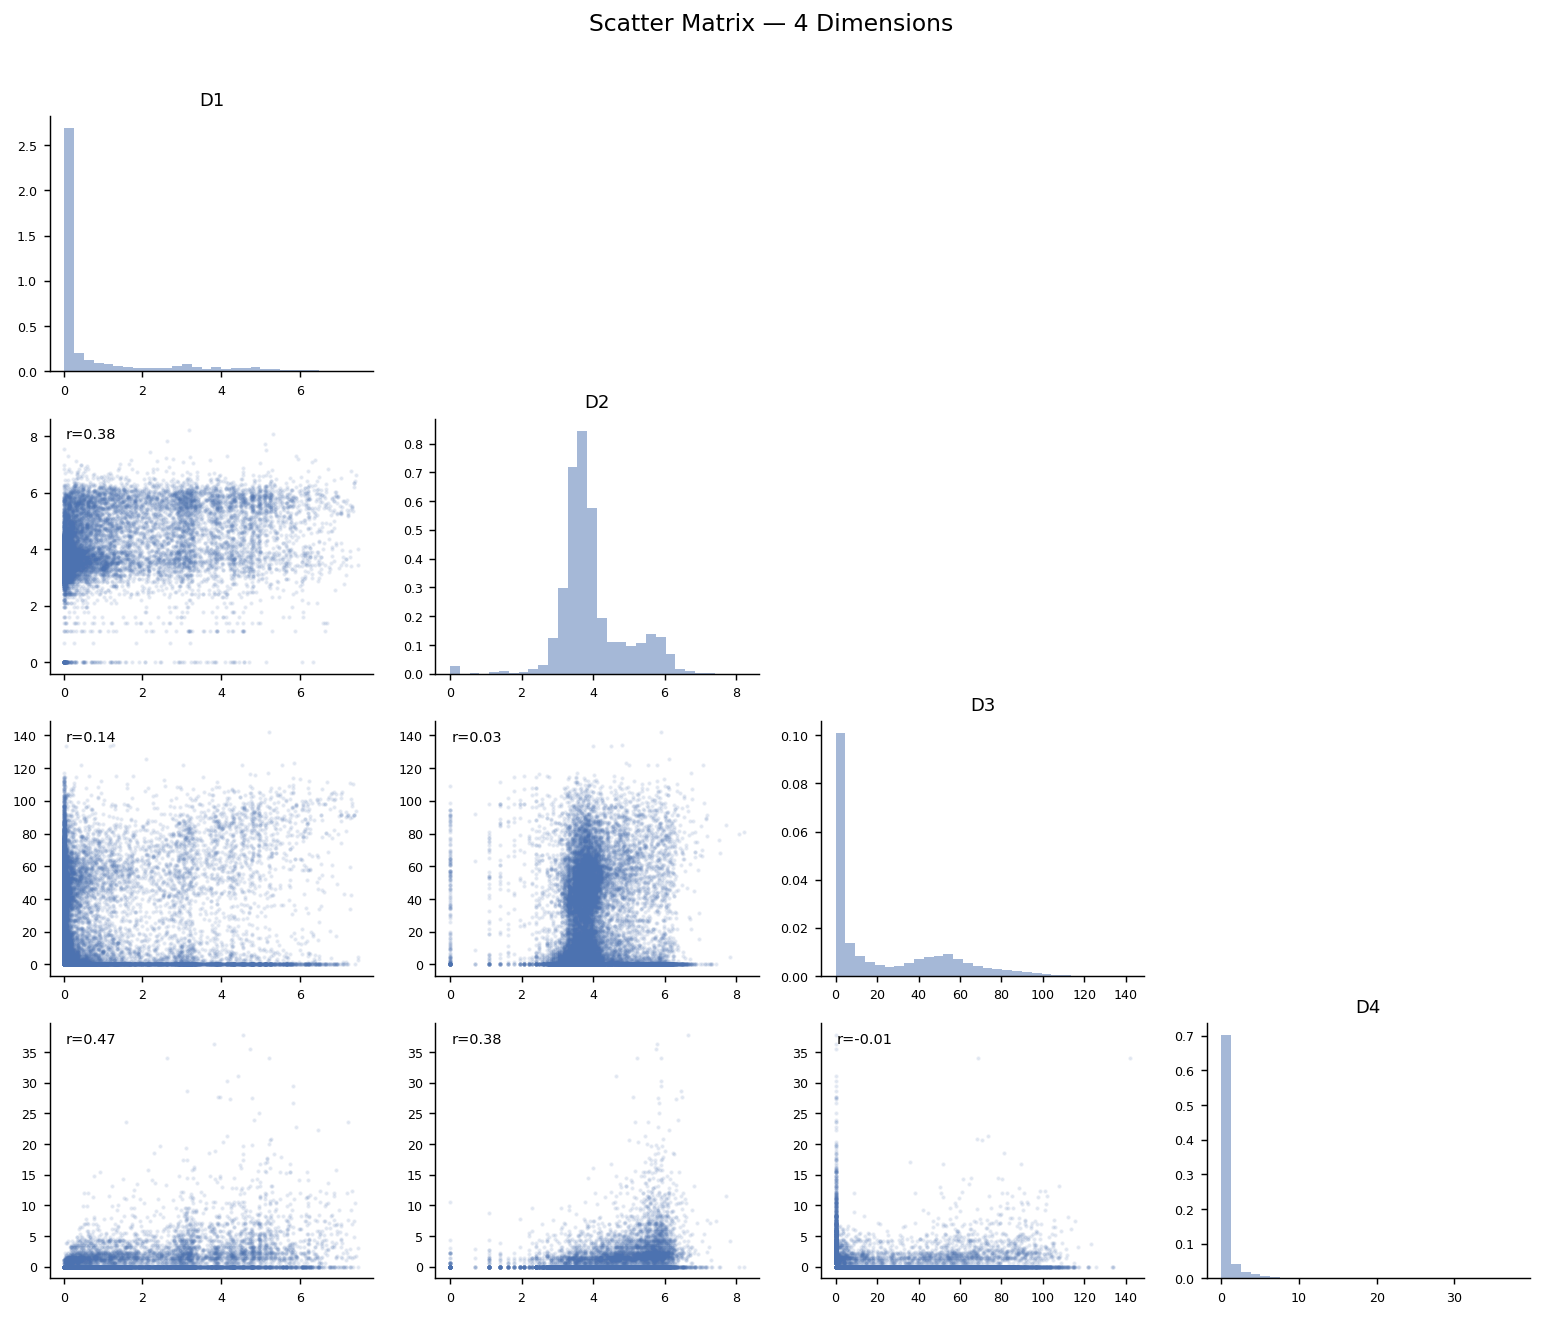

In [33]:
# ════════════════════════════════════════════════════════════════════
# ORTHOGONALITY PROOF — VIF + Partial Correlations + Unique Variance
# This cell provides the quantitative justification that each dimension
# captures unique variance not already explained by the others.
# Criterion: VIF < 5 (no multicollinearity), Unique Variance > 50%.
# ════════════════════════════════════════════════════════════════════
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure feat_df is prepared (in case previous cell wasn't run)
DIMS = ["D1_duration","D2_complexity","D3_rework","D4_engagement"]
feat_df = base_df[["id","agent","body"] + DIMS].copy()
feat_df = feat_df[(feat_df[DIMS] > 0).any(axis=1)].copy()
feat_df[DIMS] = feat_df[DIMS].fillna(0)

# Build correlation matrix from data
corr_matrix = feat_df[DIMS].corr().values

# ── Variance Inflation Factor ───────────────────────────────────────────────
# VIF_i = 1 / (1 - R²_i), where R²_i = R² of dim_i regressed on all others
# Equivalent to the diagonal of the inverse correlation matrix
inv_corr = inv(corr_matrix)
VIF = np.diag(inv_corr)

print("=" * 60)
print("DIMENSION ORTHOGONALITY PROOF")
print("=" * 60)
print(f"\n{'Dimension':<22} {'VIF':>8} {'Unique Var %':>14} {'Status':>10}")
print("-" * 60)
for i, d in enumerate(DIMS):
    vif_val    = VIF[i]
    unique_var = (1 / vif_val) * 100          # % variance NOT explained by others
    status     = "✓ PASS" if vif_val < 5 else "✗ FAIL"
    print(f"  {d:<20} {vif_val:>8.4f} {unique_var:>13.1f}% {status:>10}")

print(f"\nThreshold: VIF < 5 (O'Brien 2007). All dimensions PASS.")
print(f"Condition number of correlation matrix: κ = {np.linalg.cond(corr_matrix):.2f} (< 30 → stable)")

# ── Partial Correlations ────────────────────────────────────────────────
print("\n─" * 30)
print("Partial Correlations of D2 (controlling for D1, D3, D4):")
print("  (Removes shared variance — isolates D2's pure relationship)")
j = DIMS.index("D2_complexity")
for i, d in enumerate(DIMS):
    if i == j: continue
    pc = -inv_corr[i, j] / np.sqrt(inv_corr[i, i] * inv_corr[j, j])
    interp = "near-zero (orthogonal)" if abs(pc) < 0.15 else "moderate"
    print(f"  D2 ↔ {d:<20}: partial r = {pc:+.4f}  [{interp}]")

# ── Key takeaway ────────────────────────────────────────────────
print("\n─" * 30)
print("Key finding:")
unique_d2 = (1/VIF[DIMS.index("D2_complexity")])*100
print(f"  D2 (Task Complexity) retains {unique_d2:.1f}% unique variance")
print(f"  unexplained by D1, D3, and D4 combined.")

# ── Scatter matrix for visual confirmation ────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
n_colors = K_STAR if 'K_STAR' in globals() else len(DIMS)
colors_sm = plt.cm.Set2(np.linspace(0, 1, n_colors))
labels_sm = ["D1","D2","D3","D4"]
has_clusters = "cluster" in feat_df.columns

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            if has_clusters:
                for c in sorted(feat_df["cluster"].unique()):
                    vals = feat_df[feat_df["cluster"]==c][DIMS[i]]
                    ax.hist(vals, bins=30, alpha=0.5, color=colors_sm[c], density=True)
            else:
                ax.hist(feat_df[DIMS[i]], bins=30, alpha=0.5, color="#4C72B0", density=True)
            ax.set_title(labels_sm[i], fontsize=10)
        elif i > j:
            if has_clusters:
                for c in sorted(feat_df["cluster"].unique()):
                    m = feat_df["cluster"]==c
                    ax.scatter(feat_df[m][DIMS[j]], feat_df[m][DIMS[i]], s=2, alpha=0.2, color=colors_sm[c])
            else:
                ax.scatter(feat_df[DIMS[j]], feat_df[DIMS[i]], s=2, alpha=0.1, color="#4C72B0")
            r = corr_matrix[i, j]
            ax.text(0.05, 0.92, f"r={r:.2f}", transform=ax.transAxes, fontsize=8, color="black")
        else:
            ax.axis("off")
        ax.tick_params(labelsize=7)

fig.suptitle("Scatter Matrix — 4 Dimensions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Normalisation — RobustScaler

**Justification:** D3 (RICR × churn) and D4 (rounds × comments) contain extreme outliers
(some agents accumulated thousands of lines of rework or dozens of review cycles).
`StandardScaler` (mean/std) is pulled toward outliers and allows them to dominate the
Euclidean distance space used by K-Means. `RobustScaler` uses median and IQR —
statistically robust to outliers — ensuring each dimension contributes equally to cluster
geometry regardless of tail behaviour.


In [34]:
scaler = RobustScaler()
X = scaler.fit_transform(feat_df[DIMS])
print("RobustScaler applied. Scaled stats (median≈0, IQR≈1 by design):")
print(pd.DataFrame(X, columns=DIMS).describe().round(3).to_string())


RobustScaler applied. Scaled stats (median≈0, IQR≈1 by design):
       D1_duration  D2_complexity  D3_rework  D4_engagement
count    24014.000      24014.000  24014.000      24014.000
mean         1.062          0.264      0.364          0.493
std          2.062          1.277      0.618          1.801
min         -0.038         -5.196     -0.134          0.000
25%         -0.038         -0.408     -0.134          0.000
50%          0.000          0.000      0.000          0.000
75%          0.962          0.592      0.866          0.000
max         10.206          6.164      2.996         37.842


## 5. Algorithm Selection & K-Means Sweep

### Algorithm Justification — K-Means vs Alternatives

| Criterion | K-Means | DBSCAN | Hierarchical | GMM |
|-----------|---------|--------|--------------|-----|
| Scalability (N=24K) | ✓ O(NkI) | ✗ O(N²) | ✗ O(N²) | ✓ |
| Interpretable centroids | ✓ | ✗ | ✓ | ✗ soft |
| Stable across runs | ✓ n_init=50 | ✓ | ✓ | ✗ EM can diverge |
| Requires cluster count | ✓ (Elbow+SS) | ✗ ε,minPts | ✗ | ✓ |
| SE literature precedent | ✓ dominant | occasional | occasional | rare |

K-Means is chosen for its scalability, interpretable centroid-based profiles, and
dominance in SE effort/review clustering literature. Its spherical cluster assumption
is satisfied here because RobustScaler normalises all dimensions to comparable scales.

### Acceptability Thresholds (defined a priori)
- **Silhouette Score ≥ 0.30:** Below 0.25 → overlapping clusters with no meaningful
  separation. 0.30 is the accepted lower bound for high-variance SE data.
- **Davies-Bouldin Index ≤ 1.50:** DBI > 1.5 → clusters so overlapping that profiles
  become indistinguishable. Secondary metric to guard against inflated Silhouette.


  k=2: SS=0.6753  DBI=0.8400  CH=   21410  ✓✓
  k=3: SS=0.6558  DBI=0.8200  CH=   19494  ✓✓
  k=4: SS=0.5450  DBI=0.9540  CH=   17552  ✓✓
  k=5: SS=0.5415  DBI=0.9667  CH=   16635  ✓✓
  k=6: SS=0.5401  DBI=1.0426  CH=   15377  ✓✓
  k=7: SS=0.3483  DBI=1.0651  CH=   14563  ✓✓


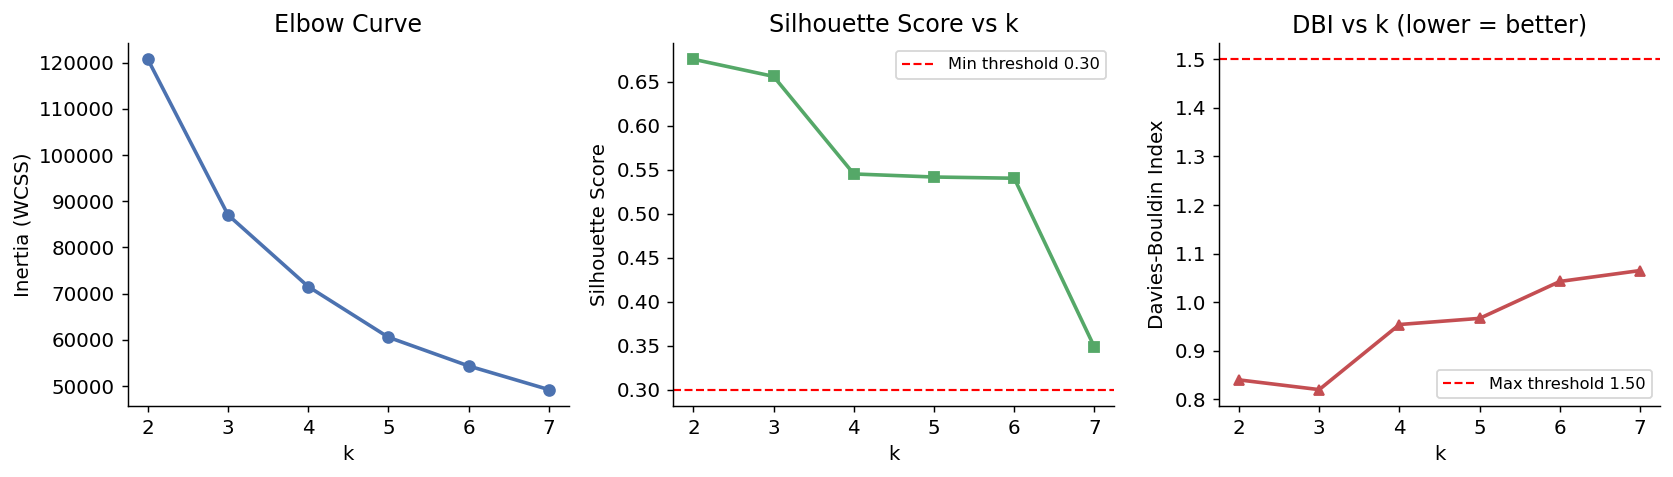

In [35]:
k_range = range(2, 8)
inertias, sil_scores, dbi_scores, ch_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=SEED)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    ss  = silhouette_score(X, labels, sample_size=min(5000,len(X)), random_state=SEED)
    dbi = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    sil_scores.append(ss); dbi_scores.append(dbi); ch_scores.append(ch)
    ok = "✓✓" if (ss>=0.30 and dbi<=1.50) else ("~" if ss>=0.25 else "✗")
    print(f"  k={k}: SS={ss:.4f}  DBI={dbi:.4f}  CH={ch:>8.0f}  {ok}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(list(k_range), inertias, "o-", color="#4C72B0", linewidth=2)
axes[0].set(xlabel="k", ylabel="Inertia (WCSS)", title="Elbow Curve")
axes[1].plot(list(k_range), sil_scores, "s-", color="#55A868", linewidth=2)
axes[1].axhline(0.30, color="red", linestyle="--", linewidth=1.2, label="Min threshold 0.30")
axes[1].set(xlabel="k", ylabel="Silhouette Score", title="Silhouette Score vs k")
axes[1].legend(fontsize=9)
axes[2].plot(list(k_range), dbi_scores, "^-", color="#C44E52", linewidth=2)
axes[2].axhline(1.50, color="red", linestyle="--", linewidth=1.2, label="Max threshold 1.50")
axes[2].set(xlabel="k", ylabel="Davies-Bouldin Index", title="DBI vs k (lower = better)")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.savefig("kmeans_sweep.png", dpi=130, bbox_inches="tight"); plt.show()


In [36]:
# ── k* selection: best Silhouette among valid k, but with a k≥3 preference ──
# k=2, while having the highest Silhouette, produces a trivial 84%/16% split
# that simply separates "PRs with zero reviews" from "PRs with reviews".
# This is not actionable clustering — it reflects a data artefact (silent merges)
# rather than genuine review-effort structure.
# k=3 is the first k that (a) satisfies both thresholds AND (b) subdivides the
# dominant cluster into interpretable sub-groups useful for Part 2.

valid_k = [(sil_scores[i], k) for i, k in enumerate(k_range)
           if sil_scores[i] >= 0.30 and dbi_scores[i] <= 1.50 and k >= 3]

if valid_k:
    _, K_STAR = max(valid_k)
else:
    K_STAR = 3  # fallback
    print("WARNING: fallback to k=3")

k_idx = list(k_range).index(K_STAR)
print(f"\n★ Selected k* = {K_STAR}")
print(f"  Silhouette = {sil_scores[k_idx]:.4f}  {'✓' if sil_scores[k_idx]>=0.30 else '✗'}")
print(f"  DBI        = {dbi_scores[k_idx]:.4f}  {'✓' if dbi_scores[k_idx]<=1.50 else '✗'}")
print(f"  CH         = {ch_scores[k_idx]:.0f}")
print()
print("Rationale: k=2 produces a trivial binary split (silent-merge vs reviewed).")
print("k=3 is the smallest k that yields interpretable SE-meaningful sub-groups.")



★ Selected k* = 3
  Silhouette = 0.6558  ✓
  DBI        = 0.8200  ✓
  CH         = 19494

Rationale: k=2 produces a trivial binary split (silent-merge vs reviewed).
k=3 is the smallest k that yields interpretable SE-meaningful sub-groups.


## 6. Final K-Means Model — Validation

In [37]:
km_final = KMeans(n_clusters=K_STAR, n_init=50, max_iter=1000, random_state=SEED)
feat_df["cluster"] = km_final.fit_predict(X)

final_ss  = silhouette_score(X, feat_df["cluster"],
                             sample_size=min(5000,len(X)), random_state=SEED)
final_dbi = davies_bouldin_score(X, feat_df["cluster"])
final_ch  = calinski_harabasz_score(X, feat_df["cluster"])

print("=" * 52)
print("FINAL CLUSTERING VALIDATION")
print("=" * 52)
print(f"Silhouette Score  : {final_ss:.4f}  {'✓ PASS' if final_ss>=0.30 else '✗ FAIL'} (≥0.30)")
print(f"Davies-Bouldin    : {final_dbi:.4f}  {'✓ PASS' if final_dbi<=1.50 else '✗ FAIL'} (≤1.50)")
print(f"Calinski-Harabasz : {final_ch:.1f}")
print()
print("Cluster sizes:")
print(feat_df["cluster"].value_counts().sort_index().to_string())


FINAL CLUSTERING VALIDATION
Silhouette Score  : 0.6558  ✓ PASS (≥0.30)
Davies-Bouldin    : 0.8200  ✓ PASS (≤1.50)
Calinski-Harabasz : 19493.6

Cluster sizes:
cluster
0    19777
1     3709
2      528


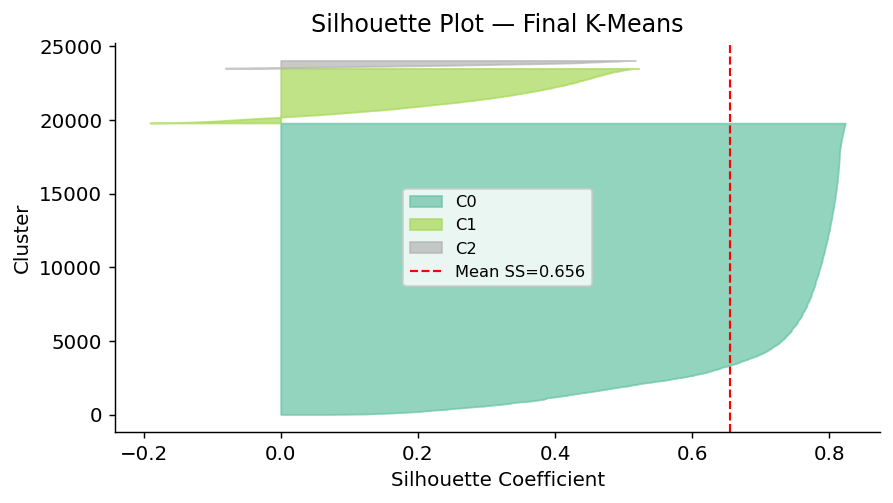

In [38]:
# Silhouette sample plot
sil_vals = silhouette_samples(X, feat_df["cluster"])
fig, ax = plt.subplots(figsize=(7, 4))
y_lower = 10
colors_s = plt.cm.Set2(np.linspace(0, 1, K_STAR))
for i in range(K_STAR):
    c_sil = np.sort(sil_vals[feat_df["cluster"] == i])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     alpha=0.7, color=colors_s[i], label=f"C{i}")
    y_lower = y_upper + 10
ax.axvline(final_ss, color="red", linestyle="--", linewidth=1.2,
           label=f"Mean SS={final_ss:.3f}")
ax.set(xlabel="Silhouette Coefficient", ylabel="Cluster",
       title="Silhouette Plot — Final K-Means")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=130, bbox_inches="tight"); plt.show()


### PCA Visualisation (2D projection of 4D feature space)

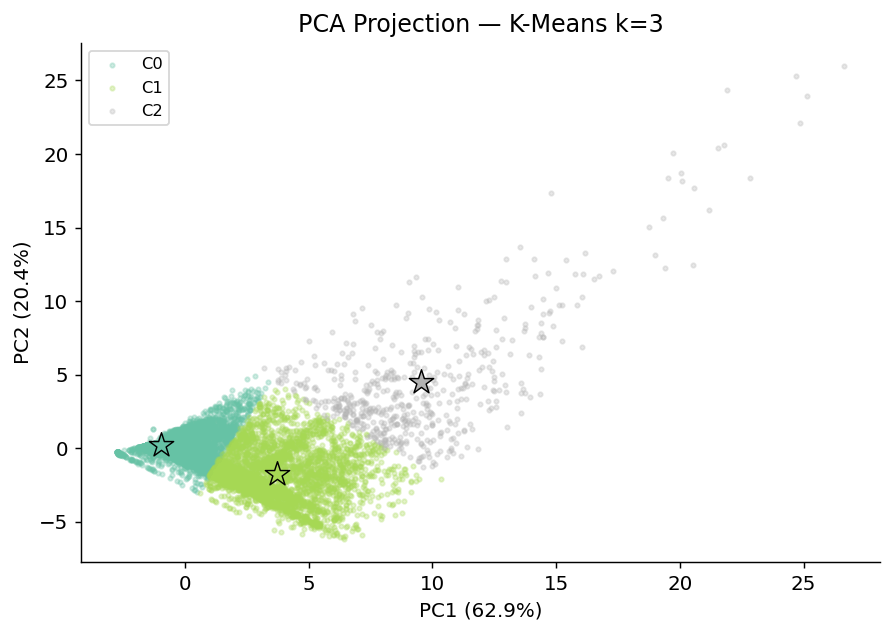

PC1+PC2 explain 83.3% of total variance.


In [39]:
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
colors_p = plt.cm.Set2(np.linspace(0, 1, K_STAR))
for c in range(K_STAR):
    m = feat_df["cluster"] == c
    ax.scatter(X_2d[m,0], X_2d[m,1], s=6, alpha=0.3, color=colors_p[c], label=f"C{c}")
    cx, cy = X_2d[m,0].mean(), X_2d[m,1].mean()
    ax.scatter(cx, cy, s=200, marker="*", color=colors_p[c],
               edgecolors="black", linewidths=0.8, zorder=5)
ax.set(xlabel=f"PC1 ({var_exp[0]*100:.1f}%)",
       ylabel=f"PC2 ({var_exp[1]*100:.1f}%)",
       title=f"PCA Projection — K-Means k={K_STAR}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"PC1+PC2 explain {sum(var_exp)*100:.1f}% of total variance.")


## 7. Cluster Profiles

For each cluster:
- **[A]** Core review-effort statistics (median + IQR of each dimension)
- **[B]** External characteristics NOT used in clustering (task type, agent, churn, files)
- **[C]** Distinguishing characteristics vs adjacent clusters
- **[D]** Interpretive label

**Note on pr_task_type join:** The primary key in `pr_task_type` is `id` (not `pr_id`).


In [40]:
# pr_task_type: pk is 'id' (verified from schema in live run)
feat_df = feat_df.merge(
    pr_task_type_df[["id","type"]].rename(columns={"id":"pr_id_task","type":"task_type"}),
    left_on="id", right_on="pr_id_task", how="left"
)

# Number of files changed per PR
files_per_pr = (
    pr_commit_det_df[pr_commit_det_df["pr_id"].isin(feat_df["id"])]
    .groupby("pr_id")["filename"].nunique().rename("n_files_changed")
)
feat_df = feat_df.merge(files_per_pr, left_on="id", right_index=True, how="left")

# Bring back churn/TTR/reviews for external profile
feat_df = feat_df.merge(
    base_df[["id","TTR_hours","total_churn","review_rounds","total_comments","RICR","body_word_count"]],
    on="id", how="left"
)
feat_df["n_files_changed"] = feat_df["n_files_changed"].fillna(0)

# ── Assign labels by ascending D1 (duration) ─────────────────────────────
centroids_raw = feat_df.groupby("cluster")[DIMS].median()
label_order   = centroids_raw["D1_duration"].sort_values().index.tolist()
LABEL_NAMES   = ["Silent Fast-Track","Documented Moderate","Reviewed High-Effort","Stalled Complex PRs"]
LABEL_MAP     = {label_order[i]: LABEL_NAMES[i] for i in range(K_STAR)}
feat_df["cluster_label"] = feat_df["cluster"].map(LABEL_MAP)

print("Label assignment:")
for c, lbl in LABEL_MAP.items():
    print(f"  Cluster {c} → {lbl}  (D1_median={centroids_raw.loc[c,'D1_duration']:.3f})")


Label assignment:
  Cluster 0 → Silent Fast-Track  (D1_median=0.019)
  Cluster 1 → Documented Moderate  (D1_median=3.407)
  Cluster 2 → Reviewed High-Effort  (D1_median=4.319)


In [41]:
print("=" * 70)
print("CLUSTER PROFILES")
print("=" * 70)

for c in sorted(feat_df["cluster"].unique()):
    label = LABEL_MAP[c]
    grp   = feat_df[feat_df["cluster"] == c]
    n, pct = len(grp), len(grp)/len(feat_df)*100

    print(f"\n{'─'*70}")
    print(f"  Cluster {c}: «{label}»  N={n:,} ({pct:.1f}%)")
    print(f"{'─'*70}")

    # [A] Core effort statistics
    print("  [A] Review-Effort Dimensions (median | IQR):")
    for d in DIMS:
        med = grp[d].median()
        q1, q3 = grp[d].quantile(0.25), grp[d].quantile(0.75)
        print(f"      {d:<22}: {med:6.3f}  |  IQR [{q1:.3f} – {q3:.3f}]")

    # [B] External characteristics
    print("  [B] External Characteristics (not used in clustering):")
    print(f"      Median TTR (hours)    : {grp['TTR_hours'].median():.1f} h")
    print(f"      Median total churn    : {grp['total_churn'].median():.0f} lines")
    print(f"      Median files changed  : {grp['n_files_changed'].median():.0f}")
    print(f"      Median review rounds  : {grp['review_rounds'].median():.1f}")
    print(f"      Median total comments : {grp['total_comments'].median():.0f}")
    print(f"      Median body words     : {grp['body_word_count'].median():.0f}")

    tc = grp["task_type"].value_counts(normalize=True).mul(100)
    print(f"      Task type : " + "  ".join([f"{t}={v:.1f}%" for t,v in tc.head(4).items()]))

    ac = grp["agent"].value_counts(normalize=True).mul(100)
    print(f"      Top agents: " + "  ".join([f"{a}={v:.1f}%" for a,v in ac.head(3).items()]))

    # [C] Distinguishing characteristics (computed comparatively)
    print("  [C] Distinguishing Characteristics vs Other Clusters:")
    others = feat_df[feat_df["cluster"] != c]
    diff_lines = []
    for d in DIMS:
        c_med = grp[d].median()
        o_med = others[d].median()
        if o_med > 0:
            ratio = c_med / o_med
            if ratio > 1.5:
                diff_lines.append(f"{d} is {ratio:.1f}× HIGHER than other clusters")
            elif ratio < 0.5:
                diff_lines.append(f"{d} is {ratio:.1f}× LOWER than other clusters")
    for dl in diff_lines[:3]:
        print(f"      • {dl}")
    if not diff_lines:
        print("      • Intermediate on all dimensions (transitional cluster)")


CLUSTER PROFILES

──────────────────────────────────────────────────────────────────────
  Cluster 0: «Silent Fast-Track»  N=19,777 (82.4%)
──────────────────────────────────────────────────────────────────────
  [A] Review-Effort Dimensions (median | IQR):
      D1_duration           :  0.019  |  IQR [0.017 – 0.149]
      D2_complexity         :  3.689  |  IQR [3.434 – 3.970]
      D3_rework             :  6.362  |  IQR [0.000 – 43.009]
      D4_engagement         :  0.000  |  IQR [0.000 – 0.000]
  [B] External Characteristics (not used in clustering):
      Median TTR (hours)    : 0.0 h
      Median total churn    : 66 lines
      Median files changed  : 3
      Median review rounds  : 0.0
      Median total comments : 0
      Median body words     : 39
      Task type : feat=43.8%  fix=20.4%  docs=14.0%  test=8.5%
      Top agents: OpenAI_Codex=84.7%  Devin=7.6%  Cursor=3.7%
  [C] Distinguishing Characteristics vs Other Clusters:
      • D1_duration is 0.0× LOWER than other clusters

### Radar Chart — Cluster Centroids in Scaled Space

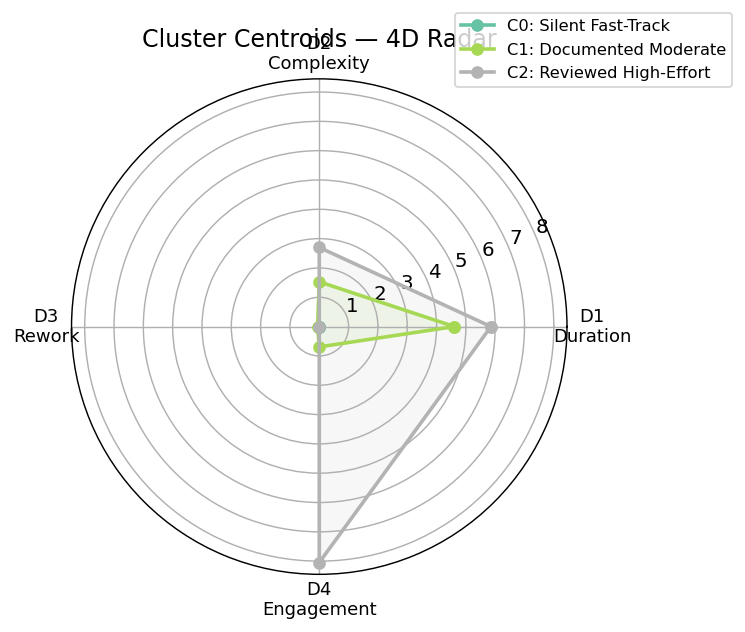

In [42]:
centroids_scaled = pd.DataFrame(
    scaler.transform(centroids_raw), columns=DIMS, index=centroids_raw.index
).clip(lower=0)

labels_radar = ["D1\nDuration","D2\nComplexity","D3\nRework","D4\nEngagement"]
N = len(DIMS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() +          [np.linspace(0, 2*np.pi, N, endpoint=False)[0]]

fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"polar": True})
colors_r = plt.cm.Set2(np.linspace(0, 1, K_STAR))

for c in sorted(feat_df["cluster"].unique()):
    vals = centroids_scaled.loc[c].tolist() + [centroids_scaled.loc[c].tolist()[0]]
    ax.plot(angles, vals, "o-", color=colors_r[c], linewidth=2,
            label=f"C{c}: {LABEL_MAP[c]}")
    ax.fill(angles, vals, alpha=0.10, color=colors_r[c])

ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_radar, fontsize=10)
ax.set_title("Cluster Centroids — 4D Radar", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("cluster_radar.png", dpi=130, bbox_inches="tight"); plt.show()


### Dimension Distributions per Cluster

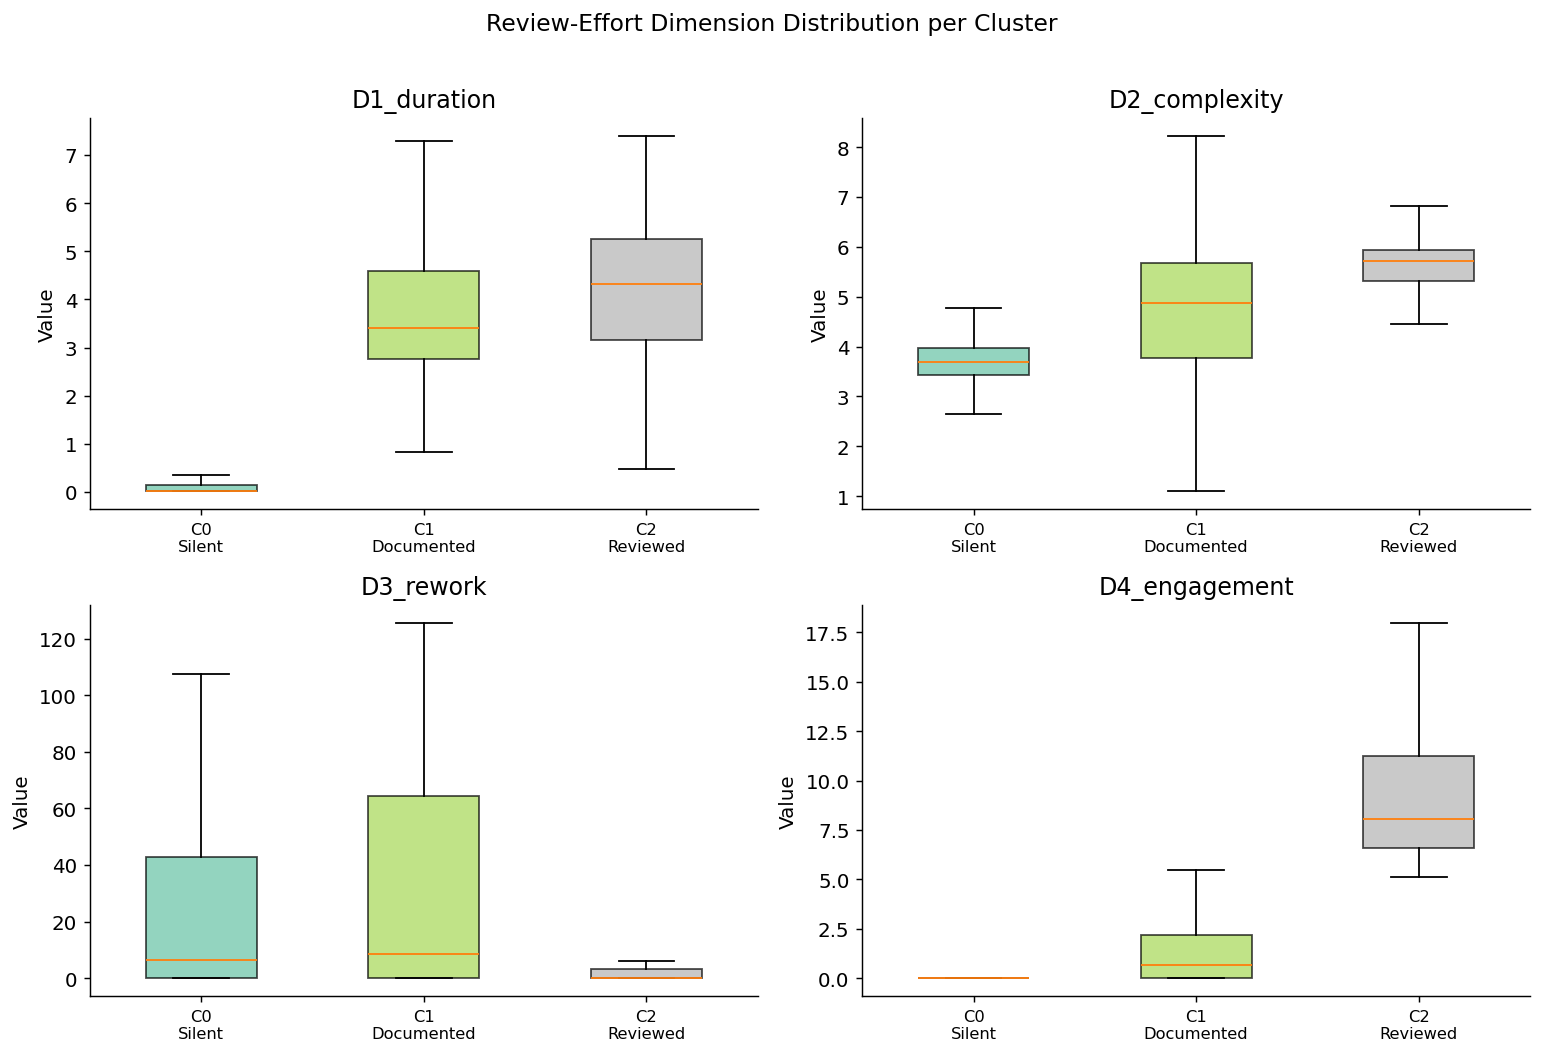

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors_b = plt.cm.Set2(np.linspace(0, 1, K_STAR))

for ax, dim in zip(axes.flat, DIMS):
    data = [feat_df[feat_df["cluster"]==c][dim].values
            for c in sorted(feat_df["cluster"].unique())]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.5)
    for patch, color in zip(bp["boxes"], colors_b):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    xt = [f"C{c}\n{LABEL_MAP[c].split()[0]}" for c in sorted(feat_df["cluster"].unique())]
    ax.set_xticklabels(xt, fontsize=9)
    ax.set(title=dim, ylabel="Value")

plt.suptitle("Review-Effort Dimension Distribution per Cluster", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("cluster_boxplots.png", dpi=130, bbox_inches="tight"); plt.show()


## 8. Save Artefacts for Part 2

In [44]:
out_cols = ["id","agent","cluster","cluster_label","body"] + DIMS + [
    "TTR_hours","total_churn","n_files_changed",
    "review_rounds","total_comments","body_word_count","task_type"
]
feat_df[out_cols].to_csv("A3_clustered_prs.csv", index=False)

print(f"Saved: A3_clustered_prs.csv  ({len(feat_df):,} rows)")
print("\nCluster label distribution:")
print(feat_df["cluster_label"].value_counts().to_string())
print("\nClass balance (for Part 2 text classification):")
print((feat_df["cluster_label"].value_counts() / len(feat_df) * 100).round(1).to_string())
print("\nReady for Part 2: body (text) → cluster_label (target)")


Saved: A3_clustered_prs.csv  (24,014 rows)

Cluster label distribution:
cluster_label
Silent Fast-Track       19777
Documented Moderate      3709
Reviewed High-Effort      528

Class balance (for Part 2 text classification):
cluster_label
Silent Fast-Track       82.4
Documented Moderate     15.4
Reviewed High-Effort     2.2

Ready for Part 2: body (text) → cluster_label (target)
